In [83]:
#import libreries.. 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore",category=FutureWarning)  #handle the futrue Warnings

In [44]:
from sklearn.datasets import load_iris

In [45]:
# load dataset and convert the DATAFRAME.
dataset = load_iris()
data = pd.DataFrame(dataset.data, columns=dataset.feature_names)

In [46]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [47]:
data.info()  # About DATA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [48]:
data.isnull().sum()  # Missing value 

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [49]:
data.shape  # DATASET Size

(150, 4)

In [50]:
data.describe()  

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [62]:
data["target"] = dataset.target  #Insert target

In [64]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [67]:
data.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [69]:
data["target"].value_counts()
# 0 --> Setosa
# 1 --> Versicolor
# 2 --> Virginica

target
0    50
1    50
2    50
Name: count, dtype: int64

<Figure size 500x600 with 0 Axes>

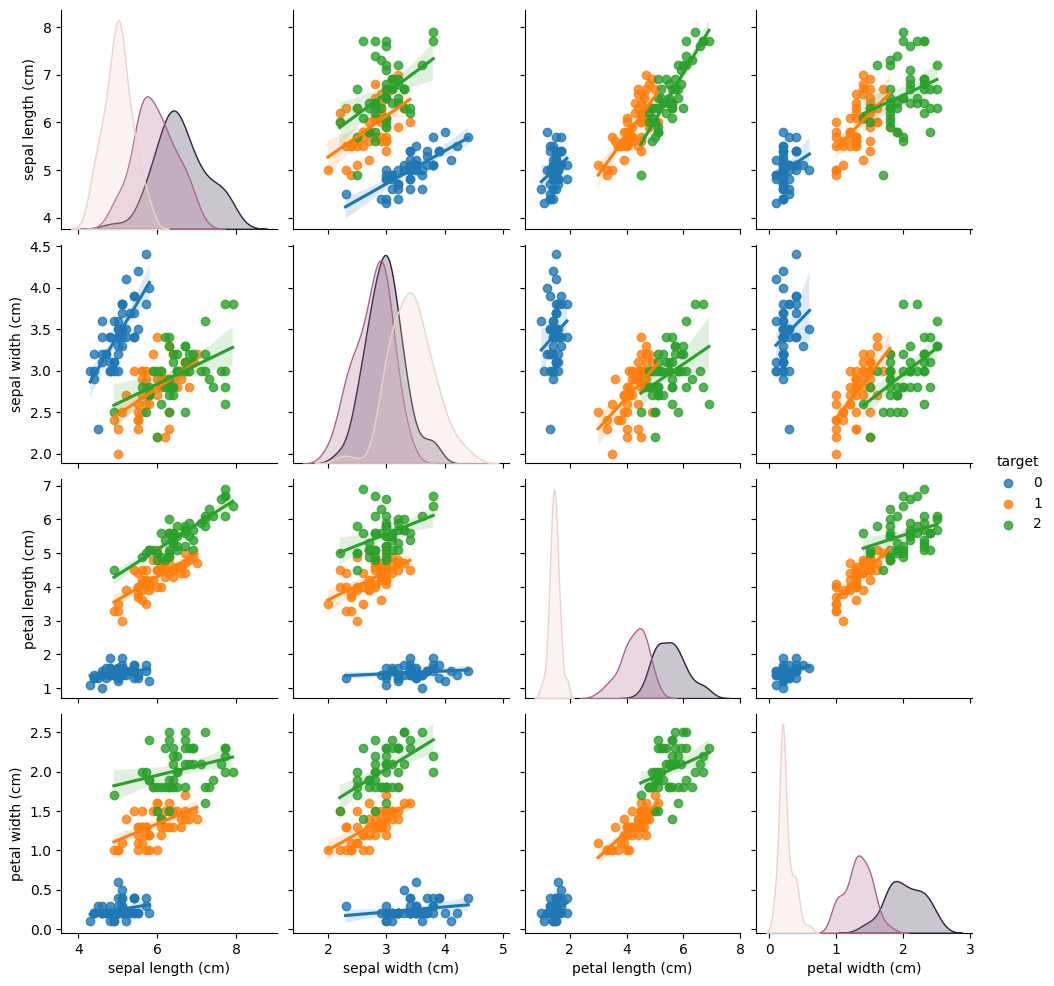

In [66]:
# look the data in Pair plot with compaired by target

plt.figure(figsize=(5, 6))
sns.pairplot(data,kind="reg",hue = "target")
plt.show()

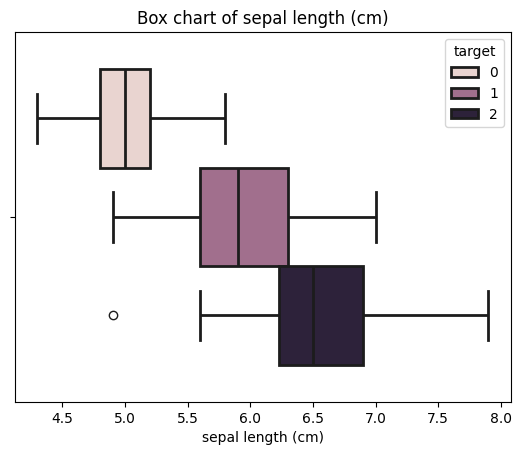

In [84]:
# look the BOX plot --> sepal length with target 

sns.boxplot(x="sepal length (cm)",data=data,hue="target",linewidth=2,linecolor="gray")
plt.title("Box chart of sepal length (cm)")
plt.show()

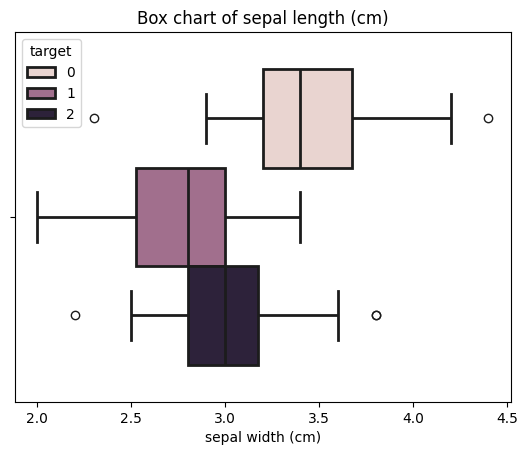

In [85]:
# look the BOX plot --> sepal width with target 

sns.boxplot(x="sepal width (cm)",data=data,hue="target",linewidth=2,linecolor="gray")
plt.title("Box chart of sepal length (cm)")
plt.show()

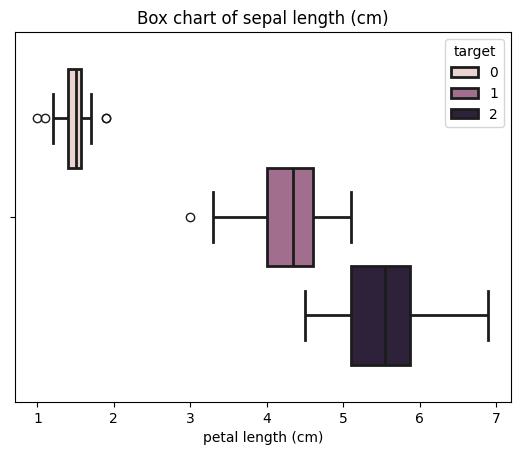

In [86]:
# look the BOX plot --> petal length with target 

sns.boxplot(x="petal length (cm)",data=data,hue="target",linewidth=2,linecolor="gray")
plt.title("Box chart of sepal length (cm)")
plt.show()

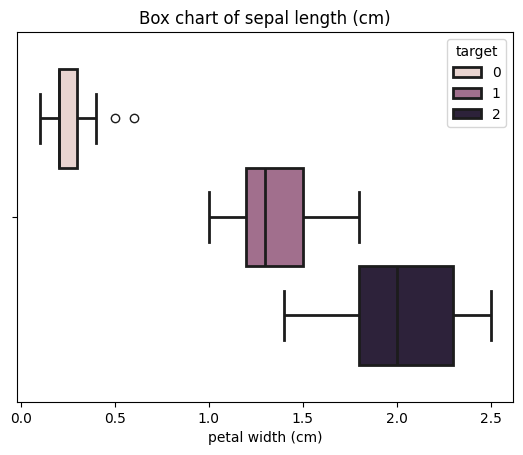

In [87]:
# look the BOX plot --> petal width with target 

sns.boxplot(x="petal width (cm)",data=data,hue="target",linewidth=2,linecolor="gray")
plt.title("Box chart of sepal length (cm)")
plt.show()

In [88]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [94]:
x = data.iloc[:,:-1]
y = data["target"]

In [95]:
# train_test_split Model
from sklearn.model_selection import train_test_split

In [97]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)  # model text

In [98]:
# Load 1st Model --> Logistric Regression
from sklearn.linear_model import LogisticRegression 

In [99]:
lr = LogisticRegression()   # train model
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [112]:
y_pred = lr.score(x_test,y_test)*100     # Predict text model
y_pred

100.0

In [105]:
# Load 2nd Model --> KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

In [106]:
knn = KNeighborsClassifier(n_neighbors=5)  # Train Model
knn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [107]:
knn.score(x_test,y_test)*100    # Predict test Model

100.0

In [128]:
# Load Matrix and find Scores
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score,precision_score,recall_score

In [129]:
cfm = confusion_matrix(y_test,lr.predict(x_test))  # Confusion Matrix 

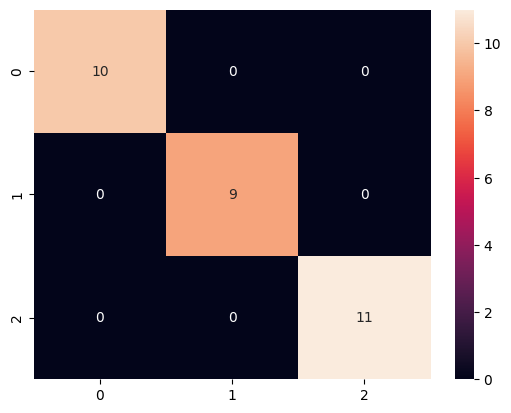

In [130]:
# look the Heat map by Confusion Matrix
sns.heatmap(cfm,annot=True)
plt.show() 

In [133]:
accuracy_score(y_test,lr.predict(x_test))*100  # Accuracy

100.0

In [140]:
f1_score(y_test,lr.predict(x_test),average=None)*100  # F1 Score

array([100., 100., 100.])

In [143]:
precision_score(y_test,lr.predict(x_test),average=None)*100  # Precision Score

array([100., 100., 100.])